# Tutorial 2: Training

This tutorial covers training the deepSCENIC model to learn gene regulatory networks from multiome data.

## Learning Objectives

After completing this tutorial, you will be able to:

- Register a genome for sequence extraction
- Configure training parameters for your dataset
- Train a deepSCENIC model with VAE + sequence components
- Monitor training progress with diagnostic plots
- Save and load trained models for later use
- (Optional) Pretrain sequence models separately
- (Optional) Fine-tune E2 matrix for transfer learning

## Setup

First, let's import the required packages and check GPU availability:

In [2]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

deepSCENIC version: 0.1.0
Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


```{note}
Training deepSCENIC requires a GPU with at least 16-32GB VRAM due to the Enformer model. Training on CPU is technically possible but extremely slow (hours vs minutes per epoch). Bringing your own model instead of the Enformer sequence embedding is also possible.
```

## Load Preprocessed Data

We'll use the preprocessed MuData from Tutorial 1. The data must contain:
- RNA and ATAC modalities with matching cells
- TF annotations (`is_tf` column in `rna.var`)
- Region-to-gene search space (`r2g` in `uns`)
- Train/test split (`split` column in `obs` and `var`)

In [3]:
import os

# Set your data directory
data_dir = "../../../../data/deepSCENIC/MM_lines/"
assert os.path.exists(data_dir), "Data directory not found"

# Load preprocessed MuData
mdata = ds.read(data_dir + "preprocessed_data.h5mu")
print(f"Cells: {mdata.n_obs} ({(mdata.obs['split'] == 'train').sum()} train, {(mdata.obs['split'] == 'test').sum()} test)")
print(f"Genes: {mdata['rna'].n_vars} ({mdata['rna'].var['is_tf'].sum()} TFs)")
print(f"Regions: {mdata['atac'].n_vars}")
mdata

deepscenic.io - INFO - Loaded ../../../../data/deepSCENIC/MM_lines/preprocessed_data.h5mu: 936 cells, 10421 genes, 281820 regions


Cells: 936 (748 train, 188 test)
Genes: 10421 (1288 TFs)
Regions: 281820


MuData object with n_obs × n_vars = 936 × 292241
  obs:	'split'
  uns:	'r2g'
  2 modalities
    rna:	936 x 10421
      var:	'n_cells', 'is_tf', 'chromosome', 'tss', 'split'
      uns:	'log1p'
      layers:	'log_norm'
    atac:	936 x 281820
      var:	'chromosome', 'start', 'end', 'split'

## Register Genome

deepSCENIC extracts DNA sequences from genomic regions to learn TF binding patterns. Before training, you must register a genome FASTA file that matches your data's reference assembly.

In [10]:
try:
    genome = ds.get_genome()
    print(f"Genome already registered: {genome.name}")
except RuntimeError:
    ds.register_genome("../../../../data/genomes/hg38.fa")

Genome already registered: hg38


## Understanding the Architecture

deepSCENIC learns gene regulatory networks through interconnected components:

```
                    DNA Sequence
                         │
                    ┌────▼────┐
                    │ Enformer │  (Pretrained DNA language model)
                    └────┬────┘
                         │
                    ┌────▼────┐
                    │ TF2rNet  │  (Maps embeddings → TF binding)
                    └────┬────┘
                         │
                    ┌────▼────┐
                    │   E1    │  TF → Region weights (learned)
                    └────┬────┘
                         │
    TF Expression ──┬────▼────┐
         │          │   VAE   │  (Encodes TF activity)
         │          └────┬────┘
         │               │
         │          ┌────▼────┐
         │          │   E2    │  Region → Gene weights (learned)
         │          └────┬────┘
         │               │
         └───────────────▼
              Gene Expression (reconstructed)
```

The model learns two key regulatory matrices:
- **E1 (TF→Region)**: Which TFs bind to which regulatory regions
- **E2 (Region→Gene)**: Which regions regulate which genes

Together, these matrices form the Gene Regulatory Network (GRN).

## Training Stages

deepSCENIC training involves multiple phases with warmup periods:

```
Epoch:    0        10        50       100
          │         │         │         │
Phase 1:  ├─────────┤         │         │
          │  VAE    │         │         │
          │  only   │         │         │
          │         │         │         │
Phase 2:  │         ├─────────┤         │
          │         │ VAE +   │         │
          │         │ TF2rNet │         │
          │         │         │         │
Phase 3:  │         │         ├─────────┤
          │         │         │  Full   │
          │         │         │ (frozen │
          │         │         │ seq.)   │
          └─────────┴─────────┴─────────┘
```

- **Phase 1 (warmup_vae)**: Train only the VAE to learn cell representations
- **Phase 2 (warmup_vae → warmup_grn)**: Joint VAE + sequence model training
- **Phase 3 (after warmup_grn)**: Freeze sequence models, refine E1/E2 matrices

This phased approach stabilizes training by letting each component learn sequentially.

## Configure Training

The key training parameters control:
- **Computational**: `epochs`, `batch_size`, `device`
- **Learning rates**: `lr` (base rate applied to all components)
- **Warmup phases**: `warmup_vae`, `warmup_grn`
- **Regularization**: `beta` (KL weight), `alpha` (E1 sparsity), `gamma` (E2 sparsity)

For most datasets, the default values work well. Adjust based on:
- **Dataset size**: Smaller datasets benefit from more epochs, smaller batch sizes
- **Sparsity preference**: Increase `alpha`/`gamma` for sparser GRNs

In [ ]:
# Simple training configuration
# For demonstration, we use 100 epochs. For real training, use 500-1000 epochs.

training_params = {
    "epochs": 100,
    "batch_size": 64,
    "lr": 1e-4,
    "warmup_vae": 10,
    "warmup_grn": 50,
    "device": device,
}

print("Training configuration:")
for key, value in training_params.items():
    print(f"  {key}: {value}")

### Advanced Configuration (Optional)

For fine-grained control over training, use `TrainingConfig`:

```python
from deepscenic.tl import TrainingConfig

config = TrainingConfig(
    epochs=1000,
    batch_size=64,
    seq_batch_size=1000,       # Sequences per batch for TF2rNet
    warmup_vae=10,
    warmup_grn=50,
    lr_vae=1e-3,               # VAE learning rate
    lr_tf2rnet=1e-3,           # Sequence model learning rate
    beta=1e-2,                 # KL divergence weight
    alpha=1e-2,                # E1 sparsity weight
    gamma=1.0,                 # E2 sparsity weight
    loss_rna="mse",            # RNA loss: 'mse', 'mae', 'cosine'
    loss_atac="mse",           # ATAC loss: 'mse', 'mae', 'bce'
)

model = ds.tl.train(mdata, config=config, device=device)
```

### Custom Sequence Models (Optional)

By default, deepSCENIC uses Enformer as its sequence encoder. However, you can provide your own PyTorch module instead. This is useful when:

- You want a lighter model that doesn't require 16GB VRAM
- You have a custom architecture tailored to your genomic context
- You want to experiment with different sequence representations

Your custom model must:
1. Accept one-hot encoded DNA sequences with shape `(batch, seq_len, 4)`
2. Return flattened embeddings with shape `(batch, bottleneck_size * emb_len)`

```python
import torch
from deepscenic.tl import TrainingConfig

# Define a simple custom sequence model
class MySequenceModel(torch.nn.Module):
    def __init__(self, seq_len=640, bottleneck_size=256, emb_len=60):
        super().__init__()
        self.conv = torch.nn.Conv1d(4, bottleneck_size, kernel_size=15, padding=7)
        self.pool = torch.nn.AdaptiveAvgPool1d(emb_len)
        self.output_dim = bottleneck_size * emb_len

    def forward(self, x):
        # x: (batch, seq_len, 4)
        x = x.transpose(1, 2)  # (batch, 4, seq_len)
        x = self.conv(x)       # (batch, bottleneck_size, seq_len)
        x = self.pool(x)       # (batch, bottleneck_size, emb_len)
        return x.flatten(1)    # (batch, bottleneck_size * emb_len)

# Use with TrainingConfig
custom_model = MySequenceModel()
config = TrainingConfig(
    sequence_model=custom_model,
    bottleneck_size=256,  # Must match your model's output
    emb_len=60,
    seq_len=640,          # Your model's expected input length
)

model = ds.tl.train(mdata, config=config, device=device)
```

```{note}
When using a custom sequence model, the `bottleneck_size` and `emb_len` parameters in the config must match your model's output dimensions. The product `bottleneck_size * emb_len` equals your model's output size.
```

## Train the Model

Now we're ready to train. The `ds.tl.train()` function:
1. Initializes the VAE, TF2rNet, and Enformer models
2. Computes initial E1 matrix from sequences (may take a few minutes)
3. Runs the training loop with the warmup schedule
4. Returns a `DeepSCENICModel` containing all trained components

```{note}
The first training run downloads the pretrained Enformer model (~1GB). Subsequent runs use the cached version. Initial E1 computation also takes several minutes as it processes all genomic sequences.
```

In [ ]:
# Train the deepSCENIC model
model = ds.tl.train(
    mdata,
    epochs=training_params["epochs"],
    batch_size=training_params["batch_size"],
    lr=training_params["lr"],
    warmup_vae=training_params["warmup_vae"],
    warmup_grn=training_params["warmup_grn"],
    device=training_params["device"],
)

print("\nTraining complete!")
print(f"Model contains {len(model.tf_names)} TFs, {len(model.gene_names)} genes, {len(model.region_names)} regions")

## Monitor Training Progress

deepSCENIC supports multiple logging backends for tracking training metrics:
- `logger='tensorboard'`: View training curves in TensorBoard
- `logger='wandb'`: Track experiments with Weights & Biases

To use TensorBoard logging during training:

```python
model = ds.tl.train(
    mdata,
    epochs=100,
    logger="tensorboard",
    log_dir="./runs/deepscenic_experiment",
    device=device,
)
```

Then launch TensorBoard:
```bash
tensorboard --logdir ./runs
```

### Check GRN Sparsity

A well-trained model should have sparse E1 and E2 matrices (most weights near zero). This reflects biological reality where TFs bind few regions, and regions regulate few genes.

In [13]:
class MySequenceModel(torch.nn.Module):
    def __init__(self, seq_len=640, bottleneck_size=256, emb_len=60):
        super().__init__()
        self.conv = torch.nn.Conv1d(4, bottleneck_size, kernel_size=15, padding=7)
        self.pool = torch.nn.AdaptiveAvgPool1d(emb_len)
        self.output_dim = bottleneck_size * emb_len

    def forward(self, x):
        # x: (batch, seq_len, 4)
        x = x.transpose(1, 2)  # (batch, 4, seq_len)
        x = self.conv(x)  # (batch, bottleneck_size, seq_len)
        x = self.pool(x)  # (batch, bottleneck_size, emb_len)
        return x.flatten(1)  # (batch, bottleneck_size * emb_len)

custom_model = MySequenceModel()

model = ds.tl.load_model(data_dir + "weights/model.pt", sequence_model=custom_model)

deepscenic.tl - INFO - Loaded model from ../../../../data/deepSCENIC/MM_lines/weights/model.pt: 10421 genes, 1288 TFs, 281820 regions


In [19]:
model.history.to_dict()

{'train': {'loss': [24.451030338511746],
  'rec_rna': [14.582470073817886],
  'rec_atac': [9.834188315957626],
  'kl': [0.034318922495937605],
  'e1_sparse': [0.0005274902214296162],
  'e2_sparse': [5.300247479058984e-05],
  'ppi': [0.0]},
 'test': {'loss': [17.420549555027737]}}

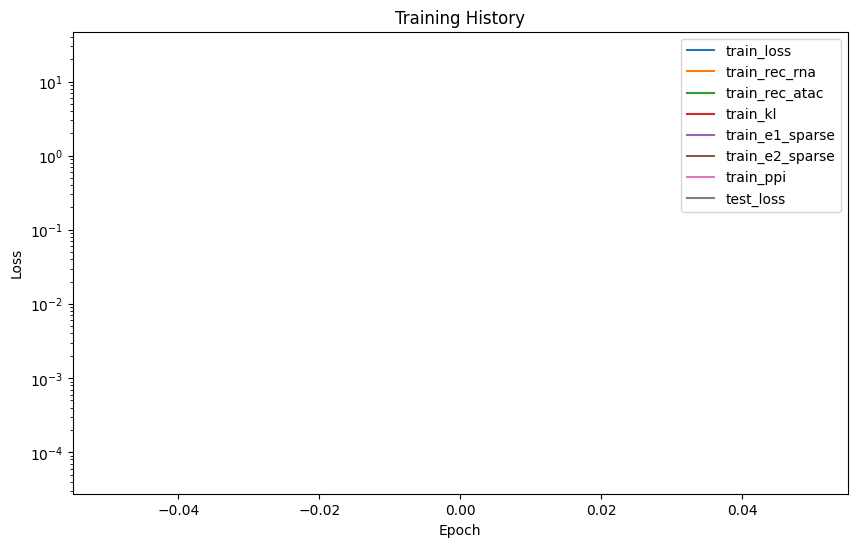

In [17]:
ds.pl.loss_curves(model, show

In [16]:
model

DeepSCENICModel(vae=DeepSCENICVAE(
  (encoder): InferenceNet(
    (mlp): Sequential(
      (0): PositiveLinear(in_features=1, out_features=128, bias=False)
      (1): Tanh()
      (2): PositiveLinear(in_features=128, out_features=128, bias=False)
      (3): Tanh()
    )
    (gaussian): GaussianSampler(
      (mu_layer): PositiveLinear(in_features=128, out_features=1, bias=False)
      (logvar_layer): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (decoder_rna): GenerativeNet(
    (mlp): Sequential(
      (0): PositiveLinear(in_features=1, out_features=128, bias=False)
      (1): Tanh()
      (2): PositiveLinear(in_features=128, out_features=128, bias=False)
      (3): Tanh()
      (4): PositiveLinear(in_features=128, out_features=1, bias=False)
    )
  )
  (decoder_atac): GenerativeNetATAC(
    (mlp): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh

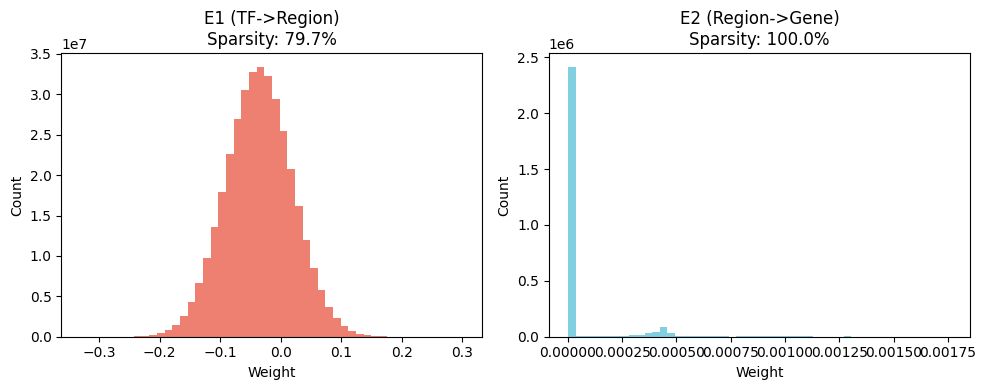

In [14]:
# Visualize weight distributions
ds.pl.sparsity_histogram(model)

### Visualize Latent Space

The VAE learns a latent representation of TF regulatory activity. Cells with similar regulatory states should cluster together.

/home/luna.kuleuven.be/u0166574/.local/share/hatch/env/virtual/deepscenic/5tHRoqxA/docs/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


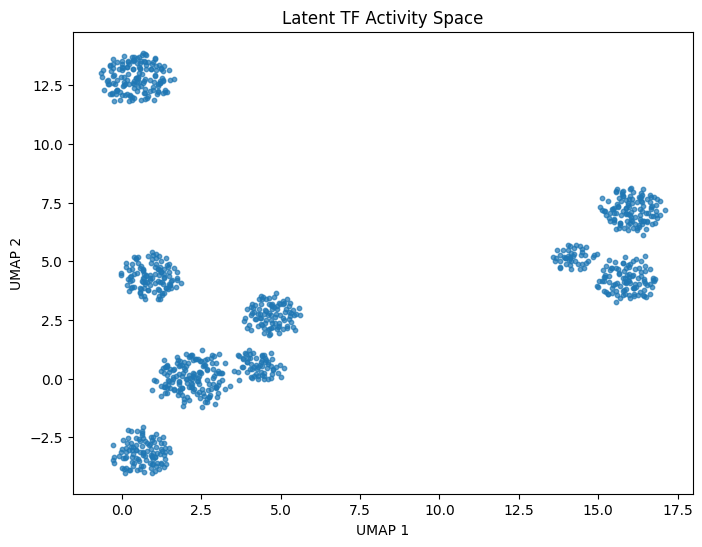

In [15]:
# UMAP of latent TF activity
# Color by any column in mdata.obs (e.g., cell type, condition)
# ds.pl.latent_umap(model, mdata, color="cell_type")
ds.pl.latent_umap(model, mdata)

## Save and Load Models

Trained models can be saved for later use. The saved file includes:
- All model weights (VAE, TF2rNet, sequence model)
- The E1 matrix cache
- Training configuration
- Feature names (TFs, genes, regions)

```{note}
Model files are large (~1GB+) when using Enformer. Models trained with custom sequence models will be smaller.
```

In [ ]:
# Save the trained model
model.save(data_dir + "deepscenic_model.pt")
print(f"Model saved to {data_dir}deepscenic_model.pt")

In [ ]:
# Load a saved model in future sessions
# loaded_model = ds.tl.load_model(data_dir + "deepscenic_model.pt", device=device)
# print(f"Loaded model with {len(loaded_model.tf_names)} TFs")

# If the model was trained with a custom sequence model, you must provide
# an instance of the same model architecture when loading:
# custom_model = MySequenceModel()  # Same architecture used during training
# loaded_model = ds.tl.load_model(
#     data_dir + "custom_model.pt",
#     device=device,
#     sequence_model=custom_model,
# )

## Optional: Pretraining Sequence Models

For large datasets, pretraining the sequence models (Enformer + TF2rNet) can improve convergence. Pretraining learns TF binding patterns from DNA sequences before joint training with the VAE.

```{note}
Pretraining is **optional**. It's most beneficial for:
- Large datasets (>10,000 cells)
- Datasets with many accessible regions (>100,000)
- When you want to reuse sequence models across multiple experiments
```

In [ ]:
# Optional: Pretrain sequence models
# pretrained = ds.tl.pretrain(
#     mdata,
#     epochs=100,
#     batch_size=256,
#     lr=1e-4,
#     device=device,
# )
# pretrained.save(data_dir + "pretrained.pt")

# Then use in training:
# model = ds.tl.train(
#     mdata,
#     pretrained_model=pretrained,
#     epochs=100,
#     device=device,
# )

## Optional: Fine-tuning E2 Matrix

Fine-tuning trains only the E2 (region→gene) matrix while keeping all other components frozen. This is useful for:
- **Transfer learning**: Adapting a trained model to new data
- **Domain adaptation**: When cell types differ between training and target data

```{note}
Fine-tuning uses a very small learning rate (1e-6) and many epochs (10,000) to gradually adjust E2 weights without disrupting learned representations.
```

In [ ]:
# Optional: Fine-tune E2 matrix
# model = ds.tl.finetune(
#     model,
#     mdata,
#     epochs=10000,
#     lr=1e-6,
#     reinit_e2=True,  # Reset E2 to near-zero before finetuning
#     device=device,
# )

## Complete Workflow Example

Here's a complete training workflow with all optional stages:

In [ ]:
# Complete deepSCENIC training workflow
#
# # 1. Register genome
# ds.genome.register_genome("/path/to/hg38.fa")
#
# # 2. Load preprocessed data
# mdata = ds.read("preprocessed_data.h5mu")
#
# # 3. (Optional) Pretrain sequence models
# pretrained = ds.tl.pretrain(mdata, epochs=100, device="cuda")
# pretrained.save("pretrained.pt")
#
# # 4. Main training
# model = ds.tl.train(
#     mdata,
#     epochs=1000,
#     batch_size=64,
#     lr=1e-4,
#     warmup_vae=10,
#     warmup_grn=50,
#     pretrained_model=pretrained,
#     logger="tensorboard",
#     log_dir="./runs",
#     device="cuda",
# )
#
# # 5. (Optional) Fine-tune for transfer learning
# model = ds.tl.finetune(model, mdata, epochs=10000, lr=1e-6, device="cuda")
#
# # 6. Save final model
# model.save("final_model.pt")
#
# # 7. Visualize results
# ds.pl.sparsity_histogram(model)
# ds.pl.latent_umap(model, mdata, color="cell_type")

## Next Steps

Now that you have a trained model, you can:

- Extract and analyze the learned GRN: {doc}`03_grn_analysis`
- Simulate gene perturbations: {doc}`04_perturbation_simulation`
- Create publication-ready visualizations: {doc}`05_visualization`